**Лекция: Недообучение и Переобучение на Примере Датасета Boston Housing**

---

### Введение

Недообучение и переобучение — две крайности, с которыми сталкиваются специалисты в области машинного обучения при построении моделей. Рассмотрим эти явления на примере датасета Boston Housing из библиотеки `sklearn`.

---

### Датасет Boston Housing

Датасет Boston Housing содержит информацию о жилье в различных районах Бостона. Основная задача — предсказать стоимость жилья на основе различных характеристик (например, уровня преступности, числа комнат, возраста зданий и т.д.).

---

### Шаг 1: Загрузка и Подготовка Данных

```python
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Загрузка данных
boston = load_boston()
X = boston.data
y = boston.target

# Разделение данных на обучающую и тестовую выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
```

---

### Шаг 2: Недообучение

Недообучение (underfitting) происходит, когда модель слишком проста, чтобы уловить все закономерности и взаимосвязи в данных.

**Моделирование:**
```python
# Использование линейной регрессии с ограниченным количеством признаков
simple_lr = LinearRegression()
simple_lr.fit(X_train[:, :3], y_train)  # Используем только первые три признака

# Оценка модели
y_pred_train = simple_lr.predict(X_train[:, :3])
y_pred_test = simple_lr.predict(X_test[:, :3])

print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred_test))
```

**Анализ:**
Если оба значения MSE высоки, это может быть признаком недообучения. Модель не смогла достаточно хорошо научиться на данных.

---

### Шаг 3: Переобучение

Переобучение (overfitting) происходит, когда модель слишком сложна и начинает улавливать шумы в данных, теряя способность к обобщению.

**Моделирование:**
```python
# Использование сложной модели, например, полиномиальной регрессии высокого порядка
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

complex_lr = LinearRegression()
complex_lr.fit(X_train_poly, y_train)

# Оценка модели
y_pred_train_poly = complex_lr.predict(X_train_poly)
y_pred_test_poly = complex_lr.predict(X_test_poly)

print("Train MSE:", mean_squared_error(y_train, y_pred_train_poly))
print("Test MSE:", mean_squared_error(y_test, y_pred_test_poly))
```

**Анализ:**
Низкий MSE на обучающих данных и высокий на тестовых данных указывают на переобучение. Модель хорошо работает на данных, на которых обучалась, но плохо обобщает на новых данных.

---

### Шаг 4: Визуализация и Анализ

```python
plt.figure(figsize=(12, 6))

# Визуализация реальных vs предсказанных значений
plt.scatter(y_test, y_pred_test, alpha=0.5, color='red', label='

Simple Model')
plt.scatter(y_test, y_pred_test_poly, alpha=0.5, color='blue', label='Complex Model')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.legend()

plt.show()
```

---

### Заключение

Недообучение и переобучение — это две проблемы, с которыми сталкиваются при построении моделей машинного обучения. Понимание и умение идентифицировать эти явления помогает создавать более эффективные и надежные модели. В идеале, модель должна находиться на золотой середине между слишком простой и слишком сложной, чтобы хорошо работать как на обучающих, так и на новых данных.

In [1]:
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Загрузка данных
boston = load_boston()
X = boston.data
y = boston.target

# Разделение данных на обучающую и тестовую выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

C:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.1)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
# Использование линейной регрессии с ограниченным количеством признаков
simple_lr = LinearRegression()
simple_lr.fit(X_train[:, :3], y_train)  # Используем только первые три признака

# Оценка модели
y_pred_train = simple_lr.predict(X_train[:, :3])
y_pred_test = simple_lr.predict(X_test[:, :3])

print("Train MSE:", mean_squared_error(y_train, y_pred_train))
print("Test MSE:", mean_squared_error(y_test, y_pred_test))

Train MSE: 64.44086532704351
Test MSE: 49.29711017165215


In [3]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

complex_lr = LinearRegression()
complex_lr.fit(X_train_poly, y_train)

# Оценка модели
y_pred_train_poly = complex_lr.predict(X_train_poly)
y_pred_test_poly = complex_lr.predict(X_test_poly)

print("Train MSE:", mean_squared_error(y_train, y_pred_train_poly))
print("Test MSE:", mean_squared_error(y_test, y_pred_test_poly))

Train MSE: 8.4846823972289e-19
Test MSE: 28143.063128015307


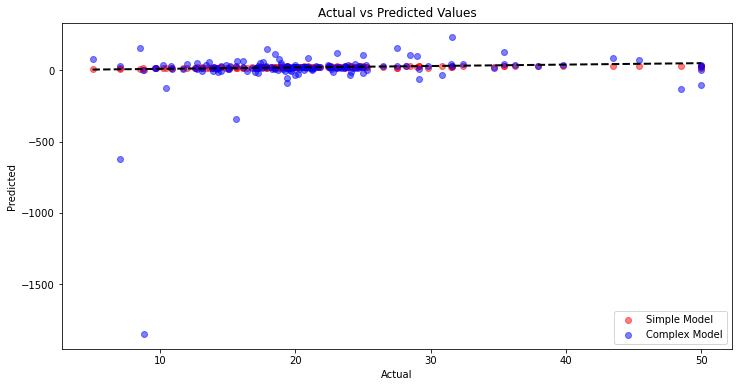

In [4]:
plt.figure(figsize=(12, 6))

# Визуализация реальных vs предсказанных значений
plt.scatter(y_test, y_pred_test, alpha=0.5, color='red', label='Simple Model')

plt.scatter(y_test, y_pred_test_poly, alpha=0.5, color='blue', label='Complex Model')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.legend()

plt.show()